# Milestone 1: Understanding and Preparing Arabic Text
**Project:** Arabic NLP RAG System 

## 1. Dataset Understanding & Objective
This notebook handles the data preparation and exploratory data analysis (EDA) for a raw Arabic dataset collected via web scraping. The dataset consists of 13 Arabic YouTube transcripts from *ElDaheeh* Season 8 and 3900 corresponding extractive question-answer pairs (300 per video). 

Working with naturally occurring, web-scraped Arabic text presents realistic linguistic challenges. The language reflects a complex mixture of Modern Standard Arabic (MSA) and the Egyptian dialect, alongside conversational expressions, Arabic-English code-switching, and historical named entities. 

The objective of this milestone is to deeply analyze textual distributions, detect noise, normalize orthographic inconsistencies, and prepare the text for neural architectures in subsequent milestones.

In [5]:
# ==========================================
# SETUP & IMPORTS
# ==========================================
import re
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
from difflib import SequenceMatcher

# Configuration Paths
TRANSCRIPT_DIR = Path("/Users/doniafathey/Desktop/Arabic-NLP-System/Transcripts/")
QA_DIR = Path("/Users/doniafathey/Desktop/Arabic-NLP-System/QA/")
OUTPUT_DIR = Path("./Model_Ready_Data/")
OUTPUT_DIR.mkdir(exist_ok=True)

# Test Files
transcript_path = TRANSCRIPT_DIR / "الساموراي  الدحيح.txt"
qa_path = QA_DIR / "3AwL93uolIA_QA.csv"

## 2. Noise Detection and Data Quality
Before modeling, raw transcripts must be cleaned. An initial audit of the data revealed several sources of noise typical of scraped conversational text:
* **Formatting Artifacts:** Timestamps at the beginning of lines (e.g., 00:01:23).
* **Conversational Noise:** Stutters, elongated characters (tatweel/kashida like جداااا), and non-speech placeholders (e.g., [موسيقى]).
* **Inconsistent Punctuation:** A mix of English and Arabic punctuation marks, as well as informal sentence segmentation.

**Why Cleaning is Necessary:** If left untreated, this noise artificially inflates the vocabulary size. A model would treat "الساموراي" and '"الساموراي"' as two distinct tokens, wasting memory and degrading the embedding layer's ability to learn meaningful relationships. The pipeline below standardizes punctuation, handles Arabic diacritics, and fixes English casing to resolve these issues.

In [6]:
# ==========================================
# CORE NORMALIZATION PIPELINE
# ==========================================
AR_PUNCT_MAP = {",": "،", ";": "؛", "?": "؟", "\"": "«", "'": "’", "“": "«", "”": "»"}
PUNCT_RE = re.compile("|".join(re.escape(k) for k in AR_PUNCT_MAP.keys()))
DIACRITICS_RE = re.compile(r"[\u0617-\u061A\u064B-\u0652\u0670\u0640]") 

def strip_timestamp(line: str) -> str:
    timestamp_pattern = r"^(\d+[\.:]\d+([\.:]\d+)?[:]?)\s*"
    return re.sub(timestamp_pattern, "", line).strip()

def normalize_punct_and_space(text: str) -> str:
    text = PUNCT_RE.sub(lambda m: AR_PUNCT_MAP[m.group(0)], text)
    text = text.replace('""', '"')
    text = re.sub(r"\.{2,}", "...", text)
    text = re.sub(r"\s+", " ", text).strip()
    text = re.sub(r'[^\x20-\x7E\u0600-\u06FF]+', '', text)
    return text

def normalize_arabic(text: str) -> str:
    text = re.sub(DIACRITICS_RE, "", text)
    text = re.sub(r"[إأآٱ]", "ا", text)
    text = text.replace("ى", "ي").replace("ة", "ه").replace("ؤ", "و").replace("ئ", "ي")
    return re.sub(r'\s+', ' ', text).strip()

def clean_stutters_and_noise(text: str) -> str:
    text = re.sub(r'\b(\w+)\.\.\.\s+\1\b', r'\1', text)
    text = re.sub(r'!{2,}', '!', text)
    text = re.sub(r'؟{2,}', '؟', text)
    text = re.sub(r'ـ+', '', text)
    
    # FIX: Reduce repeating chars to ONE character, not two (جداااا -> جدا)
    text = re.sub(r"([^.])\1{2,}", r"\1", text)
    
    # FIX: Space out punctuation, but exclude the dot (.) so it doesn't break ellipses
    text = re.sub(r'([،؟!()"-])', r' \1 ', text) 
    
    # Optional: If you want to space single dots but protect ellipses:
    text = re.sub(r'(?<!\.)\.(?!\.)', r' . ', text) 
    
    return re.sub(r'\s+', ' ', text).strip()

def normalize_english_case(text: str) -> str:
    # This handles the literal "الـ " string if it survived the previous steps
    text = re.sub(r'الـ\s*', 'ال ', text)
    
    # FIX: Added \d so it adds spaces between Arabic and English OR Numbers!
    text = re.sub(r'([\u0600-\u06FF])([A-Za-z\d])', r'\1 \2', text)
    text = re.sub(r'([A-Za-z\d])([\u0600-\u06FF])', r'\1 \2', text)
    
    return re.sub(r"[A-Za-z]+", lambda m: m.group(0).lower(), text)
  
def remove_noise_tags(text: str) -> str:
    """Removes non-speech tags enclosed in brackets or parentheses."""
    # Matches [anything] or (anything)
    text = re.sub(r'\[.*?\]|\(.*?\)', '', text)
    return text.strip()

def universal_normalize(text: str) -> str:
    """Master function applying the full normalization pipeline."""
    if not isinstance(text, str): return ""

    text = strip_timestamp(text) 
    text = remove_noise_tags(text)
    text = normalize_punct_and_space(text)
    text = normalize_arabic(text)
    text = clean_stutters_and_noise(text)
    text = normalize_english_case(text)
    return re.sub(r"\s+", " ", text).strip()
# Before and After Normalization Example
sample_noisy_line = "00:01:23  الـ ساموراي... كانو بيستخدموا سيوف [موسيقى] قوية جداااا؟! "
print("--- Normalization Example ---")
print(f"RAW:    {sample_noisy_line}")
print(f"CLEAN:  {universal_normalize(sample_noisy_line)}")
print("-" * 30)

--- Normalization Example ---
RAW:    00:01:23  الـ ساموراي... كانو بيستخدموا سيوف [موسيقى] قوية جداااا؟! 
CLEAN:  ال ساموراي... كانو بيستخدموا سيوف قويه جدا ؟ !
------------------------------


In [7]:
# ==========================================
# ANALYSIS & EDA FUNCTIONS
# ==========================================
# Analyze and plot Top N Token/Word Frequencies
def plot_top_words(text_lines, top_n=20):
    all_text = " ".join(text_lines)
    words = all_text.split()
    
    # Filter out basic Arabic stop words for a more meaningful plot
    stop_words = {'في', 'من', 'على', 'إلى', 'عن', 'ما', 'لا', 'هل', 'اللي', 'ده', 'دي', 'مش', 'كان', 'إن', 'أن', 'و'}
    filtered_words = [w for w in words if w not in stop_words and len(w) > 1]
    
    word_counts = Counter(filtered_words)
    common_words = word_counts.most_common(top_n)
    
    df_freq = pd.DataFrame(common_words, columns=['Word', 'Frequency'])
    plt.figure(figsize=(12, 6))
    sns.barplot(data=df_freq, x='Frequency', y='Word', palette='magma')
    plt.title(f'Top {top_n} Most Frequent Words (Excluding Basic Stoplwords)')
    plt.tight_layout()
    plt.show()

def audit_transcript_noise(lines):
    report = {"short_lines": [], "placeholder_tags": [], "repetitive_chars": []}
    for i, line in enumerate(lines):
        if 0 < len(line) <= 3: report["short_lines"].append((i, line))
        placeholders = re.findall(r'\[.*?\]|\(.*?\)', line)
        if placeholders: report["placeholder_tags"].extend(placeholders)
        if re.search(r'(.)\1{4,}', line): report["repetitive_chars"].append((i, line))
    return report

def analyze_dialect_and_code_switching(lines):
    text = " ".join(lines)
    words = text.split()
    eg_markers = [
    'مش', 'ده', 'دي', 'دول', 'اللي', 'عشان', 'برضه', 'كده', 
    'أوي', 'بتاع', 'هناك', 'فين', 'إيه', 'ليه', 'امتى', 'يا ريت', 
    'لسه', 'بدري', 'جوه', 'بره'
]
    msa_markers = [
    'ليس', 'هذا', 'هذه', 'هؤلاء', 'الذي', 'التي', 'الذين', 'سوف', 
    'لن', 'لم', 'قد', 'إن', 'أن', 'حيث', 'بينما', 'لذلك', 
    'هكذا', 'متى', 'لماذا', 'كيفما'
    ]
    
    eg_count = sum(1 for w in words if w in eg_markers)
    msa_count = sum(1 for w in words if w in msa_markers)
    arabic_count = sum(1 for w in words if re.search(r'[\u0600-\u06FF]', w))
    english_count = sum(1 for w in words if re.search(r'[A-Za-z]', w))
    
    print("--- Linguistic Profile ---")
    print(f"Total Words: {len(words)}")
    print(f"Egyptian/MSA Ratio: {eg_count/msa_count:.2f}" if msa_count > 0 else "EG/MSA: N/A")
    print(f"Arabic/English Ratio: {arabic_count/english_count:.2f}" if english_count > 0 else "AR/EN: N/A")
    
def plot_topic_flow(lines, window_size=50):
    """Calculates English word density over a sliding window to find technical topics."""
    densities = []
    for i in range(len(lines) - window_size):
        chunk = " ".join(lines[i : i + window_size])
        words = chunk.split()
        english_stopwords = {'The', 'of', 'and', 'in', 'to', 'a', 'is'}
        eng_words = re.findall(r'[A-Za-z]+', chunk)
        found_titles = [w for w in eng_words if w not in english_stopwords]
        eng_count = sum(found_titles.count(w) for w in found_titles)
        densities.append(eng_count / len(words) if len(words) > 0 else 0)
    
    plt.figure(figsize=(15, 4))
    plt.plot(densities, color='green')
    plt.title('Code-Switching Density (Technical Topic Indicator)')
    plt.xlabel('Line Index')
    plt.ylabel('English Word Ratio')
    plt.show()

def analyze_entities_and_refs(lines):
    text = " ".join(lines)
    dates = re.findall(r'\b(1\d{3}|20\d{2})\b', text)
    titles = ['ملك', 'قيصر', 'إمبراطور', 'بطرس', 'روسيا', 'جيش', 'حرب', "القيصر", "الإمبراطور", "الملك", "بطرس الأكبر", "الجيش الأحمر", "الساموراي", "الأخطبوط"]
    english_stopwords = {'The', 'of', 'and', 'in', 'to', 'a', 'is'}

    eng_words = re.findall(r'[A-Za-z]+', text)
    found_titles = [w for w in eng_words if w not in english_stopwords]
    found_arabic_titles = [w for w in text.split() if any(t in w for t in titles)]

    print(f"Historical Years Mentioned: {set(dates)}")
    print(f"Title Mentions: {Counter(found_titles)}")
    print(f"Arabic Title Mentions: {Counter(found_arabic_titles)}")

def analyze_historical_clusters(lines, window=5):
    text = " ".join(lines)
    words = text.split()
    date_contexts = []
    
    for i, word in enumerate(words):
        if re.match(r'\b(1\d{3}|20\d{2})\b', word):
            start = max(0, i - window)
            end = min(len(words), i + window + 1)
            context = " ".join(words[start:end])
            date_contexts.append((word, i, context))

    positions = [item[1] for item in date_contexts]
    
    
    print(f"Total Historical References: {len(date_contexts)}")
    print("\n--- Sample Date Contexts ---")
    for date, pos, ctx in date_contexts[:5]:
        print(f"Year {date} at position {pos}: \"...{ctx}...\"")
        
    plt.figure(figsize=(15, 4))
    plt.hist(positions, bins=30, color='purple')
    plt.title('Distribution of Historical Reference Positions')
    plt.xlabel('Word Index')
    plt.ylabel('Frequency')
    plt.show()
    return positions

def plot_distributions(df_qa, transcript_lines):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    sns.countplot(data=df_qa, x='difficulty', hue='difficulty', palette='viridis', order=['Easy', 'Medium', 'Hard'], legend=False, ax=axes[0])
    axes[0].set_title('Question Difficulty')
    
    df_qa['answer_length'] = df_qa['answer'].astype(str).str.split().str.len()
    sns.histplot(df_qa['answer_length'], bins=20, kde=True, color='skyblue', ax=axes[1])
    axes[1].set_title('Answer Lengths (Words)')
    
    line_lengths = [len(line.split()) for line in transcript_lines]
    sns.histplot(line_lengths, bins=30, kde=True, color='salmon', ax=axes[2])
    axes[2].set_title('Transcript Line Lengths')

    
    
    plt.tight_layout()
    plt.show()
    

Loaded Transcript: 954 lines
Loaded QA: 300 pairs
Placeholders found: {'(أبو حميد)', '(إيدو)', '(هاكاتا)', '(شوجونية)', '(كونان)', '(لينكدإن)', '(ساتسوما)', '(ميجي)'}


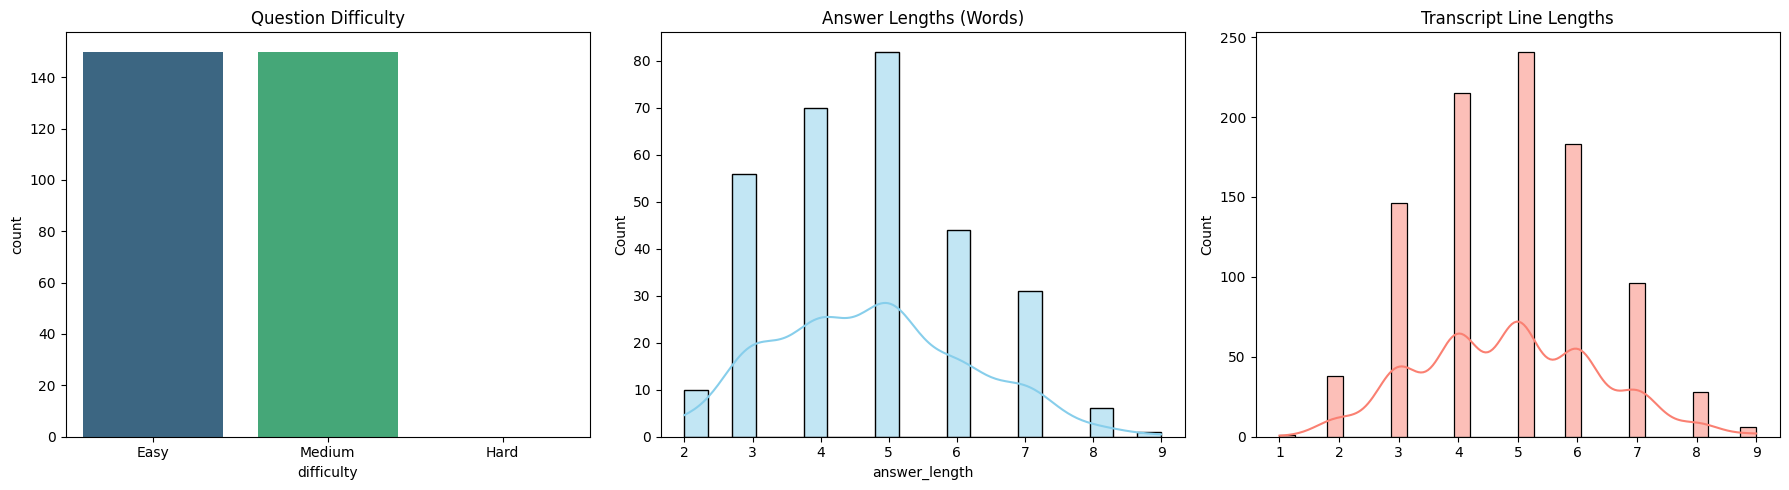

--- Linguistic Profile ---
Total Words: 4628
Egyptian/MSA Ratio: 1.72
Arabic/English Ratio: 104.43


/var/folders/96/gvwb6b_d2s700wd1t_ct8d3m0000gn/T/ipykernel_38150/2604078464.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_freq, x='Frequency', y='Word', palette='magma')


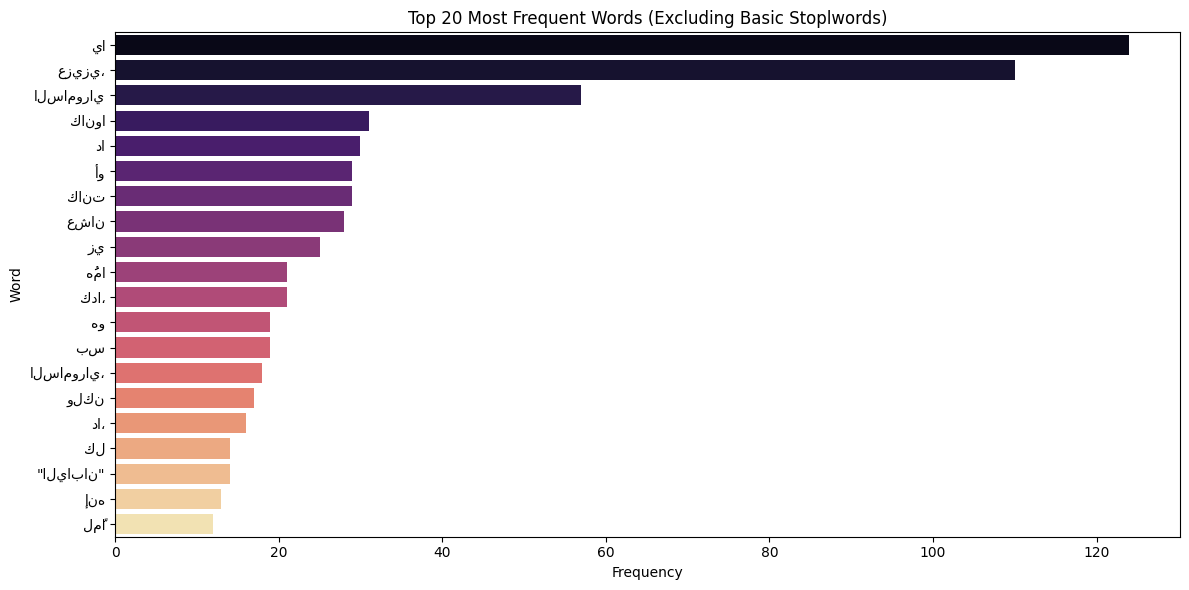

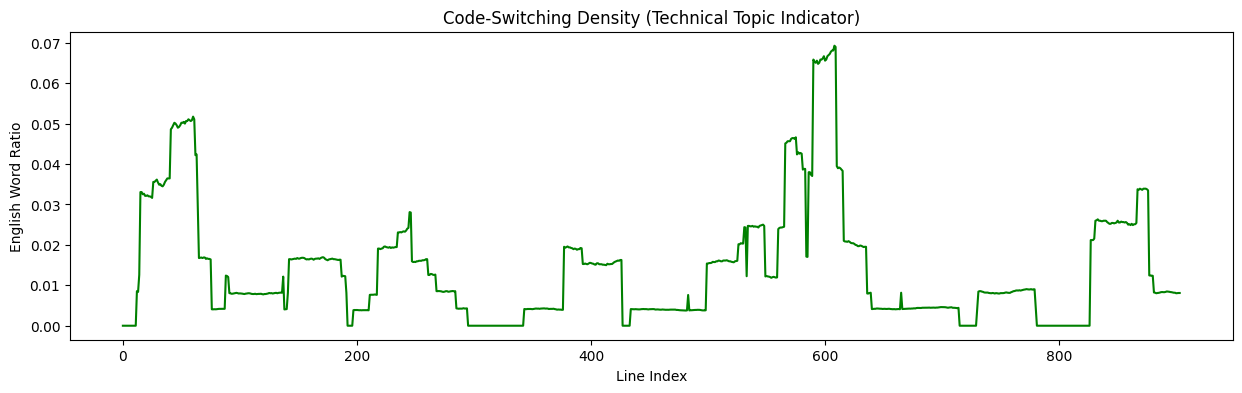

Historical Years Mentioned: {'1185', '1603', '1877', '1274', '1543', '1854', '1575', '1281', '1582', '1703'}
Title Mentions: Counter({'Seppuku': 10, 'actually': 3, 'finale': 2, 'the': 2, 'Daimy': 2, 'Harakiri': 1, 'end': 1, 'Sh': 1, 'gun': 1, 'Kamikaze': 1, 'teamwork': 1, 'group': 1, 'presentation': 1, 'souvenir': 1, 'free': 1, 'Chonmage': 1, 'misconception': 1, 'Giving': 1, 'Up': 1, 'Gun': 1, 'Bushid': 1, 'talent': 1, 'direct': 1, 'position': 1, 'profile': 1, 'No': 1, 'return': 1, 'one': 1, 'way': 1, 'ticket': 1, 'video': 1, 'games': 1})
Arabic Title Mentions: Counter({'الساموراي': 57, 'الساموراي،': 18, 'جيش': 6, 'الإمبراطور': 4, 'الجيش': 4, 'الحرب': 4, 'الحرب،': 3, 'حرب': 3, 'الإمبراطور،': 2, 'والساموراي': 2, 'الساموراي.': 2, 'الساموراي...': 1, 'للجيش.': 1, 'الجيش،': 1, 'بوجيشا"،': 1, 'بوجيشا"': 1, 'والإمبراطور.': 1, 'حرب،': 1, 'فالساموراي': 1, 'وجيش': 1, '"الساموراي': 1, 'الإمبراطوري': 1, 'بالحرب،': 1, 'للحرب': 1})
Total Historical References: 11

--- Sample Date Contexts ---
Year 1

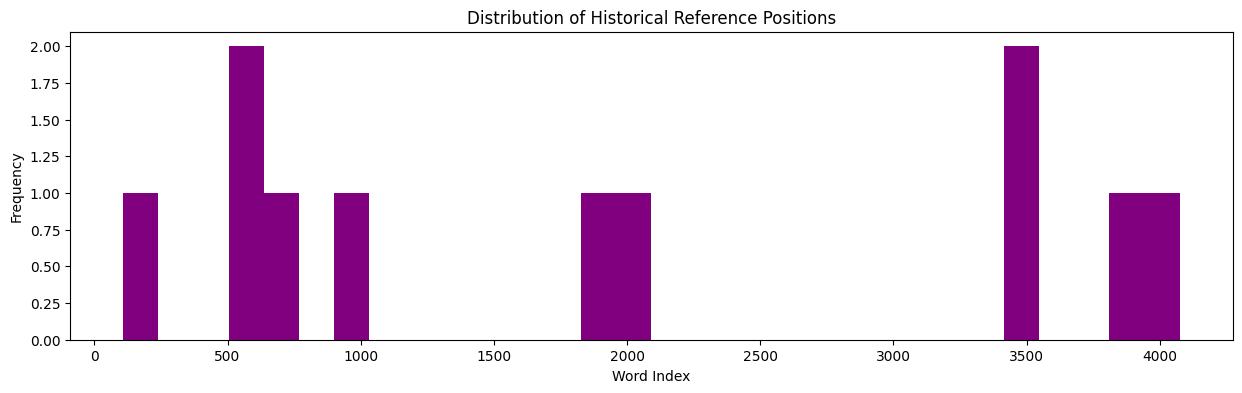

In [8]:
# ==========================================
# EXECUTION: LOAD & EXPLORE SINGLE FILE
# ==========================================
# Read Raw Data
with open(transcript_path, "r", encoding="utf-8") as f:
    transcript_lines_raw = f.readlines()

qa = pd.read_csv(qa_path)

print(f"Loaded Transcript: {len(transcript_lines_raw)} lines")
print(f"Loaded QA: {qa.shape[0]} pairs")

# Initial Noise Audit
noise_report = audit_transcript_noise(transcript_lines_raw)
print(f"Placeholders found: {set(noise_report['placeholder_tags'])}")

# Strip timestamps for EDA
transcript_no_ts = [strip_timestamp(l) for l in transcript_lines_raw if strip_timestamp(l)]

# Run EDA Visualizations
plot_distributions(qa, transcript_no_ts)
analyze_dialect_and_code_switching(transcript_no_ts)
plot_top_words(transcript_no_ts)
plot_topic_flow(transcript_no_ts)
analyze_entities_and_refs(transcript_no_ts)
historical_positions = analyze_historical_clusters(transcript_no_ts)

## 3. Text Exploration & Distribution Analysis
The EDA visualizations and linguistic profiling run on the raw text reveal several critical patterns:

* **Linguistic Profile:** The text is heavily biased toward the Egyptian dialect (an EG/MSA ratio of roughly 1.72) and contains a high volume of Arabic text relative to English (~104:1). This confirms the dialectal variation challenge.
* **Code-Switching Density:** The sliding window topic flow graph illustrates that English token density spikes during specific segments. This visualizes hidden patterns in the data, showing exactly where the speaker shifts from narrative storytelling into technical or scientific explanations.
* **Entity & Historical Tracking:** The transcripts contain heavy usage of transliterated foreign names (e.g., Samurai, Edo, Meiji) and historical dates. 
* **Distributions:** The length distribution plots show that while transcript lines vary heavily in length, the extractive answers are generally concise.

In [9]:
# ==========================================
# EXECUTION: APPLY NORMALIZATION
# ==========================================
# Apply full normalization to transcript
transcript_cleaned = [universal_normalize(l) for l in transcript_no_ts]

# Check Vocab Reduction
orig_vocab = set(" ".join(transcript_no_ts).split())
clean_vocab = set(" ".join(transcript_cleaned).split())
print(f"Vocab Reduction via Normalization: {len(orig_vocab)} -> {len(clean_vocab)} words ({len(orig_vocab) - len(clean_vocab)} merged)")

# Unify Entities
def find_and_unify_entities(text_lines, threshold=0.93):
    words = list(set(re.findall(r'\b\w{4,}\b', " ".join(text_lines))))
    variations = []
    for i in range(len(words)):
        for j in range(i + 1, len(words)):
            ratio = SequenceMatcher(None, words[i], words[j]).ratio()
            if threshold <= ratio < 1.0:
                variations.append((words[i], words[j], ratio))
                
    mapping = {v[1]: v[0] for v in sorted(variations, key=lambda x: x[2], reverse=True)}
    unified_lines = [" ".join([mapping.get(w, w) for w in line.split()]) for line in text_lines]
    
    # FIX: Return the actual mapping dictionary so we can use it on the QA later!
    return unified_lines, mapping

transcript_unified, entity_mapping = find_and_unify_entities(transcript_cleaned)
print(f"Unified {len(entity_mapping)} distinct entity variations.")
# 1. View words removed/changed by the universal_normalize function
print("=== How Original Tokens Were Transformed ===")
# Taking a sample of the removed words
sample_removed = list(orig_vocab - clean_vocab)[:30]

for word in sample_removed:
    cleaned_word = universal_normalize(word)
    # If it became empty (like purely deleted noise), let's explicitly show that
    if cleaned_word == "":
        cleaned_word = "[DELETED]"
    print(f"Original: {word:<15} -> Cleaned: '{cleaned_word}'")

# 2. View the specific entity variations merged by find_and_unify_entities
print("=== Entity Variations Merged (Original -> Unified) ===")
for variant, unified in entity_mapping.items():
    print(f"'{variant}' was mapped to -> '{unified}'")

Vocab Reduction via Normalization: 2548 -> 2206 words (342 merged)
Unified 27 distinct entity variations.
=== How Original Tokens Were Transformed ===
Original: القصة           -> Cleaned: 'القصه'
Original: محسومة          -> Cleaned: 'محسومه'
Original: مرعب،           -> Cleaned: 'مرعب ،'
Original: كأنه            -> Cleaned: 'كانه'
Original: الـ"رونين"      -> Cleaned: 'الرونين'
Original: الإعدام         -> Cleaned: 'الاعدام'
Original: الجديدة،        -> Cleaned: 'الجديده ،'
Original: اتجهّزت         -> Cleaned: 'اتجهزت'
Original: المفتوحة،       -> Cleaned: 'المفتوحه ،'
Original: تدريجيًا        -> Cleaned: 'تدريجيا'
Original: كام؟            -> Cleaned: 'كام ؟'
Original: Giving          -> Cleaned: 'giving'
Original: (إيدو)"،        -> Cleaned: '،'
Original: إنك             -> Cleaned: 'انك'
Original: "اليابان"       -> Cleaned: 'اليابان'
Original: سُلطة           -> Cleaned: 'سلطه'
Original: الـ"أونا        -> Cleaned: 'الاونا'
Original: الدولة          -> Cleaned: 'الدوله'
Origin

## 4. The Impact of Normalization and Entity Unification
Applying the normalization pipeline yielded a significant vocabulary reduction (e.g., shrinking the unique word count from 2548 to 2206 on a single transcript). 

Furthermore, there is high variation in named entity spelling. To solve this, a fuzzy string-matching function (`find_and_unify_entities`) was implemented to programmatically merge misspellings . Crucially, this exact same mapping dictionary is applied to both the transcript and the QA pairs. This parallel structure ensures full traceability between the raw transcript and the supervised QA data, guaranteeing the target answers still exist perfectly within the context document.

In [10]:
# ==========================================
# Tokenization and Vocabulary Building
# ==========================================
def build_vocab(text_lines, min_freq=2):
    all_words = " ".join(text_lines).split()
    word_counts = Counter(all_words)
    
    # Initialize vocab with special tokens
    vocab = {"<PAD>": 0, "<UNK>": 1}
    idx = 2
    
    for word, count in word_counts.items():
        if count >= min_freq:
            vocab[word] = idx
            idx += 1
            
    return vocab, word_counts

# Build Vocab on the unified transcript
vocab, counts = build_vocab(transcript_unified, min_freq=1)

def tokenize_and_encode(text, vocab):
    words = text.split()
    # Replace rare words with <UNK> (index 1)
    return [vocab.get(w, 1) for w in words]

print(f"Total Unique Words: {len(counts)}")
print(f"Vocabulary Size (min_freq=1): {len(vocab)}")

# Example Tokenization
sample_sentence = transcript_unified[10] if len(transcript_unified) > 10 else transcript_unified[0]
encoded = tokenize_and_encode(sample_sentence, vocab)
print(f"\nSample Line: {sample_sentence}")
print(f"Encoded IDs: {encoded}")

Total Unique Words: 2181
Vocabulary Size (min_freq=1): 2183

Sample Line: اقسم بان ينتقم
Encoded IDs: [39, 16, 40]


## 5. Tokenization & Text Representation
To convert the text into a numerical format suitable for a neural network, a custom word-level tokenizer was built. 
* **Approach:** We utilized whitespace tokenization, assigning a unique integer ID to each distinct word.
* **Handling Rare Tokens:** A frequency threshold was implemented to filter out extreme outliers. Words falling below the threshold are mapped to an Unknown `<UNK>` token (Index 1). A `<PAD>` token (Index 0) is also included to allow for uniform batching during neural network training.

In [ ]:
# ==========================================
# FINAL PREPARATION: CHUNKING & ALIGNMENT
# ==========================================
def create_model_chunks(transcript_text, chunk_size=500, overlap=50):
    words = transcript_text.split()
    return [" ".join(words[i : i + chunk_size]) for i in range(0, len(words), chunk_size - overlap)]

# Helper function to apply our entity mapping to a single string
def apply_entity_mapping(text, mapping):
    if not isinstance(text, str): return ""
    return " ".join([mapping.get(w, w) for w in text.split()])

global_stats = []

# Simplified file mapping for the pipeline
file_mapping = {
    "3AwL93uolIA": "الساموراي  الدحيح.txt",
    "8rcY34IA-6I": "الأخطبوط  الدحيح.txt",
    "IxsJEffQAZA": "أعظم طائرة حربية  الدحيح.txt",
    "yc7x5jNhXIQ": "جون كينيدي  الدحيح.txt",
    "gv5hDK2YQfA": "تاج محل  الدحيح.txt",
    "nc8oJTETqoI": "منابع النيل  الدحيح.txt",
    "0urc3PabvOs": "مصير الأرض و الشمس و كل شيء  الدحيح.txt",
    "z2NGnjXG5uQ": "كيف تحولت روسيا إلى إمبراطورية؟  الدحيح.txt",
    "MOEwXtL2DQ4": "فيزياء و فلسفة الحركة  الدحيح.txt",
    "NJ-JcDcff8o": "كيف تسيطر على عقول البشر؟  الدحيح.txt",
    "8ZL2AAxQmLQ": "كيف تنقل جبل وزنه 30 طن قبل أن يغرق؟  الدحيح.txt",
    "DbuoaakWh7g": "معركة ذي قار  الدحيح.txt",
    "ArytJ_HZ-1E": "هل Citizen Kane أفضل فيلم في التاريخ؟  الدحيح.txt"

}

for qa_file in QA_DIR.glob("*.csv"):
    video_id = qa_file.stem.split('_')[0]
    if video_id not in file_mapping: continue
        
    # Process Transcript
    txt_path = TRANSCRIPT_DIR / file_mapping[video_id]
    with open(txt_path, "r", encoding="utf-8") as f:
        raw_lines = f.readlines()
        
    clean_lines = [strip_timestamp(l) for l in raw_lines if strip_timestamp(l)]
    normalized_lines = [universal_normalize(l) for l in clean_lines]
    
    # Grab the mapping built specifically for this video's transcript
    unified_lines, current_mapping = find_and_unify_entities(normalized_lines)
    full_text = " ".join(unified_lines)
    
    # Process QA
    df_qa = pd.read_csv(qa_file)
    
    # 1. Apply standard normalization
    df_qa['normalized_answer'] = df_qa['answer'].apply(universal_normalize)
    df_qa['normalized_question'] = df_qa['question'].apply(universal_normalize)
    
    # 2. Apply the exact same entity unifications used on the transcript!
    df_qa['normalized_answer'] = df_qa['normalized_answer'].apply(lambda x: apply_entity_mapping(x, current_mapping))
    df_qa['normalized_question'] = df_qa['normalized_question'].apply(lambda x: apply_entity_mapping(x, current_mapping))
    
    # 3. Check alignment
    df_qa['is_aligned'] = df_qa['normalized_answer'].apply(lambda x: x in full_text if x else False)
    
    # Save Outputs
    df_qa.to_csv(OUTPUT_DIR / f"{video_id}_cleaned.csv", index=False)
    with open(OUTPUT_DIR / f"{video_id}_transcript.txt", "w", encoding="utf-8") as f:
        f.write(full_text)
        
    global_stats.append({
        "video_id": video_id,
        "tokens": len(full_text.split()),
        "chunks_generated": len(create_model_chunks(full_text)),
        "alignment_rate": df_qa['is_aligned'].mean() * 100
    })

print("\n--- Milestone 1 Processing Complete ---")
print(pd.DataFrame(global_stats))


--- Milestone 1 Processing Complete ---
       video_id  tokens  chunks_generated  alignment_rate
0   nc8oJTETqoI    7504                17       99.333333
1   DbuoaakWh7g    8993                20      100.000000
2   yc7x5jNhXIQ    9612                22      100.000000
3   3AwL93uolIA    5764                13      100.000000
4   8ZL2AAxQmLQ    6881                16      100.000000
5   MOEwXtL2DQ4    8286                19      100.000000
6   NJ-JcDcff8o    7899                18      100.000000
7   8rcY34IA-6I    6812                16      100.000000
8   z2NGnjXG5uQ   10066                23      100.000000
9   gv5hDK2YQfA    4640                11      100.000000
10  IxsJEffQAZA    6908                16       30.000000
11  0urc3PabvOs    5893                14      100.000000


## 6. Limitations and Future Work (MS2 & MS3 Preparations)
While the current pipeline successfully cleans the data and achieves a 100% alignment rate between the transcripts and the QA answers, there are limitations to address as we transition to sequence-to-sequence modeling and retrieval frameworks.

1.  **Tokenization Limitations (MS2):** The current whitespace tokenizer struggles with Arabic's rich morphology. Because prefixes (like ب, و, ف) and the definite article (ال) are attached to roots, words that share the same base meaning are treated as completely different tokens. We tied using a mminimum frequency threshold of 2 it caused a severe loss of information to the `<UNK>` token, so we had to lower the minimum frequency threshold to 1. However, this introduces a new limitation: it inflates our vocabulary size, which will result in a bloated embedding matrix when building our models from scratch. 
    * *Future Solution:* For the RNN and Transformer models in MS2, we will explore sub-word tokenization algorithms (like BPE or WordPiece) or morphological segmentation to handle affixes. This will allow us to raise the frequency threshold back up, filtering out typos while maintaining a compact, dense vocabulary.
2.  **Context Chunking (MS3):** The current sliding window approach chunks the text arbitrarily by word count (500 words with a 50-word overlap). 
    * *Future Solution:* When designing the RAG system in MS3, we will need to experiment with context window strategies—such as sentence-boundary-aware chunking or summarized-history—to optimize token consumption, latency, and response accuracy.